In [1]:
import pandas as pd
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean, cosine
from tsfresh.feature_extraction import extract_features
from tsfresh.utilities.dataframe_functions import impute
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# ========== STEP 1: DTW DISTANCE BETWEEN EACH PAIR OF CLIENTS ==========

def compute_multivariate_dtw_distance(df1, df2):
    ts1 = df1.to_numpy()  # shape: (T, D)
    ts2 = df2.to_numpy()

    min_len = min(len(ts1), len(ts2))
    ts1 = ts1[:min_len]
    ts2 = ts2[:min_len]

    dist, _ = fastdtw(ts1, ts2, dist=euclidean)
    return dist

# ========== STEP 2: FEATURE-BASED SIMILARITY ==========

def reshape_for_tsfresh(df, client_id):
    """
    Prepare DataFrame for tsfresh feature extraction:
    Columns: ['id', 'time', 'value', 'kind']
    """
    long_df = pd.DataFrame()
    for i, col in enumerate(df.columns):
        temp = pd.DataFrame({
            'id': f'{client_id}_{col}',
            'time': np.arange(len(df)),
            'value': df[col].values,
            'kind': col
        })
        long_df = pd.concat([long_df, temp])
    return long_df

In [3]:
exp_id = 'EXPERIMENT_INCOME'
dir_id = 'income_base'

folders_experiment = [f for f in glob.glob(os.path.join(f'results/{dir_id}', f'*{exp_id}*')) if os.path.isdir(f)]
# folders_experiment = [f.replace('___0', '').replace('results/density_base\\', '') for f in folders_experiment]

# ids_exp = folders_experiment[10].replace(f'results/{dir_id}\\', '').split('__')
# exp_path = 'datasets/leaks/Graeme/' + ids_exp[0] + '__' + ids_exp[1][:14] + '/'

case = 'A_62_LL_LM__LL_LH_LM_LL_LL'
case = 'D_2_LL_LH__LH_LM_LL_LL_LL'
case = 'C_65_LL_LH__LH_LL_LL_LL_LM'
exp_path = f'datasets/leaks/Graeme/{case}/'

data_clients = {}
for client in ['A', 'B', 'C', 'D', 'E']:
    aux_data = pd.read_csv(exp_path + f'Client{client}_Baseline.csv')

    aux_data['timestamp'] = pd.to_datetime(aux_data['timestamp'], unit='s')
    years = aux_data['timestamp'].dt.year
    months = aux_data['timestamp'].dt.month

    # Compute base year from the minimum timestamp
    base_year = aux_data['timestamp'].min().year

    # Continuous month index
    aux_data['label'] = (years - base_year) * 12 + (months - 1)
    aux_data.drop(columns = 'timestamp', inplace = True)
    aux_data.columns = ['v1', 'v2', 'p1', 'p2', 'p3', 'label']
    aux_data = aux_data[['label','v1', 'v2',  'p1', 'p2', 'p3']]
    aux_data = aux_data[['label', 'p1']]

    data_clients[client] = aux_data

# Assume data_clients is already loaded as described
# Each data_clients[client] is a DataFrame with 5 time series columns

clients = list(data_clients.keys())
num_clients = len(clients)

len(folders_experiment)

0

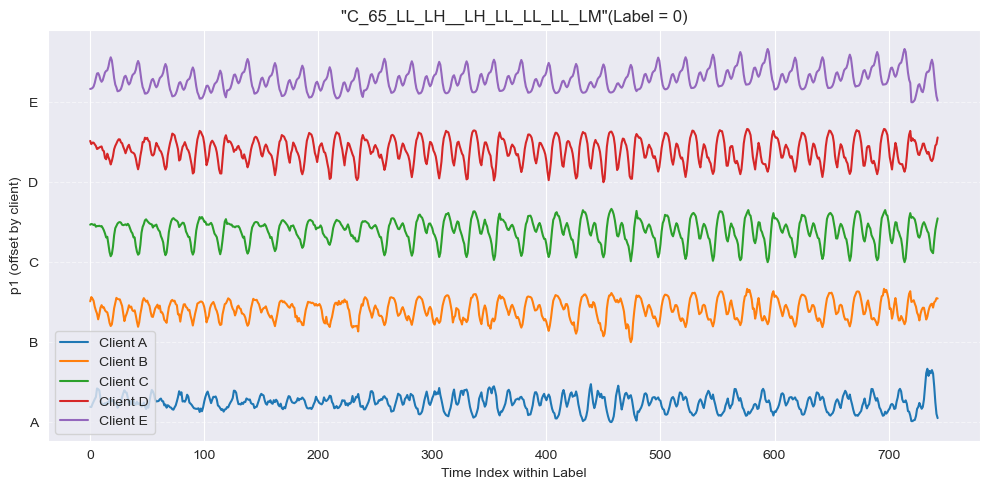

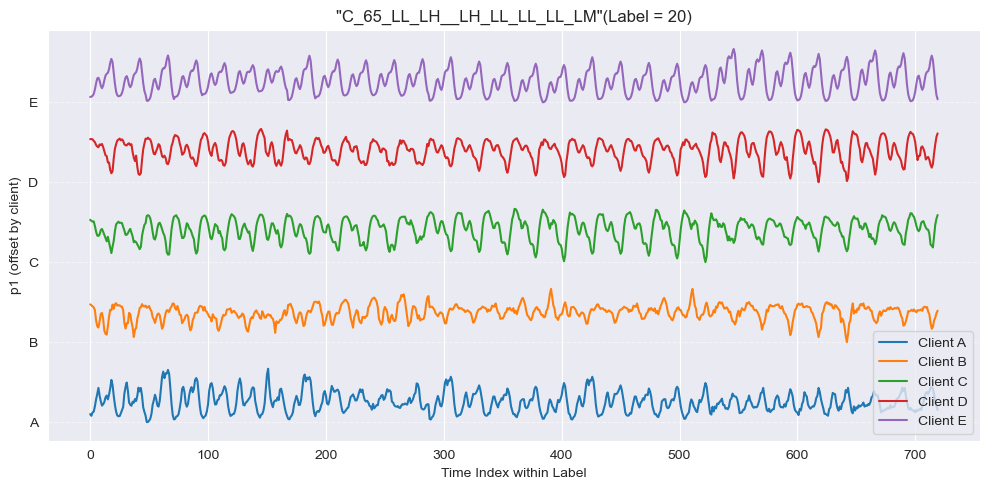

In [4]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

def plot_variable_by_labels(data_clients, variable, labels, spacing=1.5):
    """
    Plot min-max normalized variable over time for each label, with vertical spacing per client.

    Parameters:
    - data_clients: dict of DataFrames (one per client)
    - variable: str, name of the variable to plot (e.g., 'v1')
    - labels: list of int, month indices to include
    - spacing: float, vertical space between clients
    """
    client_list = sorted(data_clients.keys())

    for label in labels:
        plt.figure(figsize=(10, 5))
        for i, client in enumerate(client_list):
            df = data_clients[client]
            df_label = df[df['label'] == label]
            if df_label.empty:
                continue

            values = df_label[variable].values
            if len(values) == 0:
                continue

            # Min-max normalize
            min_val = np.min(values)
            max_val = np.max(values)
            norm_values = (values - min_val) / (max_val - min_val) if max_val > min_val else np.zeros_like(values)

            # Apply vertical offset
            offset = i * spacing
            offset_values = norm_values + offset

            plt.plot(
                range(len(offset_values)),
                offset_values,
                label=f'Client {client}',
                # marker='o'
            )

        plt.title(f'"{case}"(Label = {label})')
        plt.xlabel('Time Index within Label')
        plt.ylabel(f'{variable} (offset by client)')
        plt.yticks(
            [i * spacing for i in range(len(client_list))],
            client_list
        )
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.legend()
        plt.tight_layout()
        plt.show()


plot_variable_by_labels(data_clients, variable='p1', labels=[0, 20])

C:\Users\arthu\anaconda3\envs\TsLeaks\lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


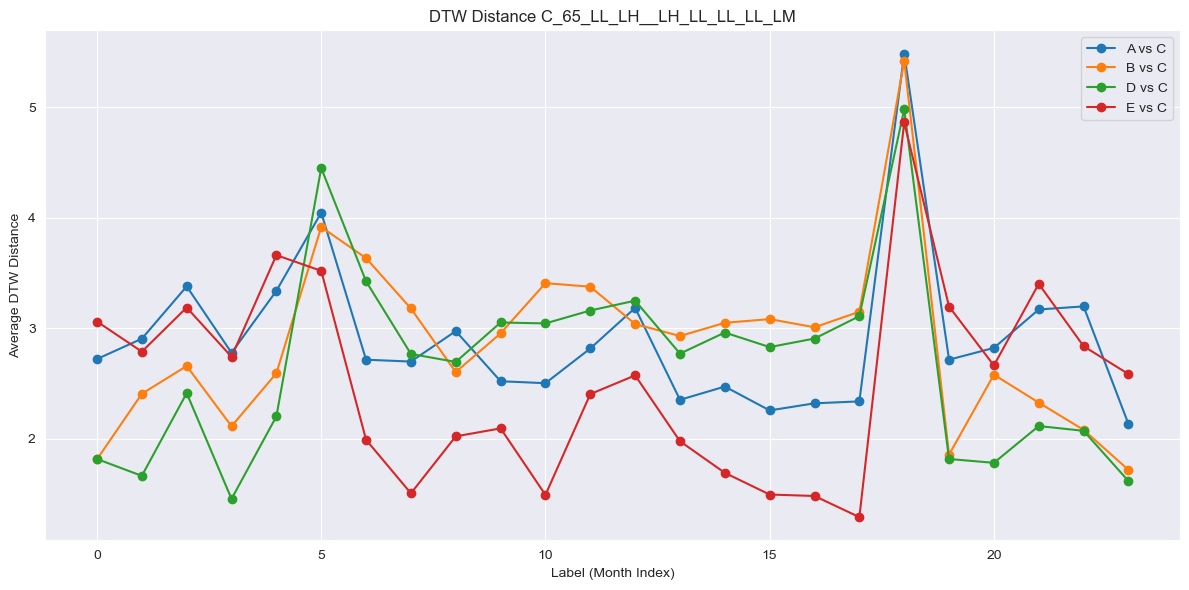

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tslearn.metrics import dtw

target_client = case[0]
clients = list(data_clients.keys())

# Step 1: Gather all unique labels
all_labels = sorted(set(label for df in data_clients.values() for label in df['label'].unique()))

# Step 2: Initialize result storage
dtw_results = {client: [] for client in clients if client != target_client}
dtw_results['label'] = []

# Step 3: Loop through all labels
for label in all_labels:
    # 3.1: Extract data for the current label
    label_data = {
        client: df[df['label'] == label].drop(columns='label')
        for client, df in data_clients.items()
        if label in df['label'].values
    }

    if target_client not in label_data or any(len(label_data[c]) == 0 for c in label_data):
        continue  # skip if any client missing data for this label

    # 3.2: Scale time series
    label_data_scaled = {}
    for client, df in label_data.items():
        scaler = StandardScaler()
        label_data_scaled[client] = scaler.fit_transform(df)

    # 3.3: Compute DTW distances for this label
    dtw_results['label'].append(label)
    for client in clients:
        if client == target_client:
            continue
        dist_sum = 0
        for col in range(label_data_scaled[client].shape[1]):
            series_target = label_data_scaled[target_client][:, col]
            series_other = label_data_scaled[client][:, col]
            dist_sum += dtw(series_target, series_other)
        dtw_results[client].append(dist_sum / 5)  # average over time series

# Step 4: Convert to DataFrame
df_dtw = pd.DataFrame(dtw_results)

# Step 5: Plot
plt.figure(figsize=(12, 6))
for client in df_dtw.columns:
    if client != 'label':
        plt.plot(df_dtw['label'], df_dtw[client], label=f'{client} vs {target_client}', marker='o')

plt.xlabel('Label (Month Index)')
plt.ylabel('Average DTW Distance')
plt.title(f'DTW Distance {case}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

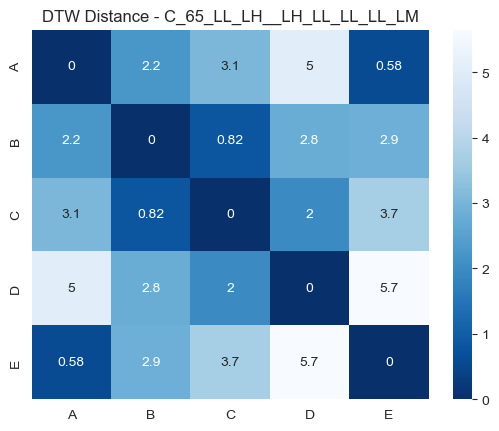

In [6]:
label = 23

dtw_distances = pd.DataFrame(index=clients, columns=clients, dtype=float)

for c1, c2 in combinations(clients, 2):
    client1_label = data_clients[c1][data_clients[c1]['label'] == label].drop(columns = 'label')
    client2_label = data_clients[c2][data_clients[c2]['label'] == label].drop(columns = 'label')

    # client1_label = data_clients[c1].drop(columns = 'label')
    # client2_label = data_clients[c2].drop(columns = 'label')

    dist = compute_multivariate_dtw_distance(client1_label.iloc[:, -1:], client2_label.iloc[:, -1:])
    dtw_distances.loc[c1, c2] = dist
    dtw_distances.loc[c2, c1] = dist

np.fill_diagonal(dtw_distances.values, 0)

# Optional visualization
sns.heatmap(dtw_distances.astype(float), annot=True, cmap="Blues_r")
plt.title(f"DTW Distance - {case}")
plt.show()

In [9]:
from itertools import product

fc_dict = {
                "time_reversal_asymmetry_statistic": [
                    {"lag": lag} for lag in range(1, 4)
                ],
                "c3": [{"lag": lag} for lag in range(1, 4)],
                "large_standard_deviation": [{"r": r * 0.05} for r in range(1, 5)],
                "autocorrelation": [{"lag": lag} for lag in range(1, 7)],
                "agg_autocorrelation": [
                    {"f_agg": s, "maxlag": 40} for s in ["mean", "median", "var"]
                ],
                "partial_autocorrelation": [{"lag": lag} for lag in range(1, 7)],
                "number_cwt_peaks": [{"n": n} for n in [1, 5]],
                "number_peaks": [{"n": n} for n in [1, 3, 5, 10, 50]],
                "binned_entropy": [{"max_bins": max_bins} for max_bins in [10]],
                "cwt_coefficients": [
                    {"widths": width, "coeff": coeff, "w": w}
                    for width in [(2, 5, 10, 20)]
                    for coeff in range(15)
                    for w in (2, 5, 10, 20)
                ],
                "spkt_welch_density": [{"coeff": coeff} for coeff in [2, 5, 8]],
                "ar_coefficient": [
                    {"coeff": coeff, "k": k} for coeff in range(10 + 1) for k in [10]
                ],
                "fft_coefficient": [
                    {"coeff": k, "attr": a}
                    for a, k in product(["real", "imag", "abs", "angle"], range(10))
                ],
                "fft_aggregated": [
                    {"aggtype": s} for s in ["centroid", "variance", "skew", "kurtosis"]
                ],
                "approximate_entropy": [
                    {"m": 2, "r": r} for r in [0.1, 0.3, 0.5, 0.7, 0.9]
                ],
                # "friedrich_coefficients": (
                #     lambda m: [
                #         {"coeff": coeff, "m": m, "r": 30} for coeff in range(m + 1)
                #     ]
                # )(3),
                # "max_langevin_fixed_point": [{"m": 3, "r": 30}],
                "linear_trend": [
                    {"attr": "pvalue"},
                    {"attr": "rvalue"},
                    {"attr": "intercept"},
                    {"attr": "slope"},
                    {"attr": "stderr"},
                ],
                # "augmented_dickey_fuller": [
                #     {"attr": "teststat"},
                #     {"attr": "pvalue"},
                #     {"attr": "usedlag"},
                # ],
                "energy_ratio_by_chunks": [
                    {"num_segments": 5, "segment_focus": i} for i in range(5)
                ],
                "lempel_ziv_complexity": [{"bins": x} for x in [2, 3, 5, 10, 100]],
                "fourier_entropy": [{"bins": x} for x in [2, 3, 5, 10, 100]],
                "permutation_entropy": [
                    {"tau": 1, "dimension": x} for x in [3, 4, 5, 6, 7]
                ],
            }

best_keys = [
    "autocorrelation",
    "partial_autocorrelation",
    "agg_autocorrelation",
    "fft_coefficient",
    "fft_aggregated",
    "spkt_welch_density",
    "fourier_entropy",
    "approximate_entropy",
    "permutation_entropy",
    "lempel_ziv_complexity",
    "linear_trend",
]

features_dict = { k : fc_dict[k] for k in best_keys }

In [10]:
# Combine all client data
all_series = pd.DataFrame()
for client in clients:
    client_label = data_clients[client][data_clients[client]['label'] == label]

    for i, col in enumerate(client_label.columns[1:]):
        features = extract_features(client_label[['label', col]], default_fc_parameters = features_dict, column_id = 'label', column_value = col, disable_progressbar=True)

        # new_cols = [c.split('__')[1] for c in features.columns]
        # features.columns = new_cols
        features['client'] = client
        features['feat'] = i
        all_series = pd.concat([all_series, features], axis = 0)

print(all_series.shape)

(5, 89)


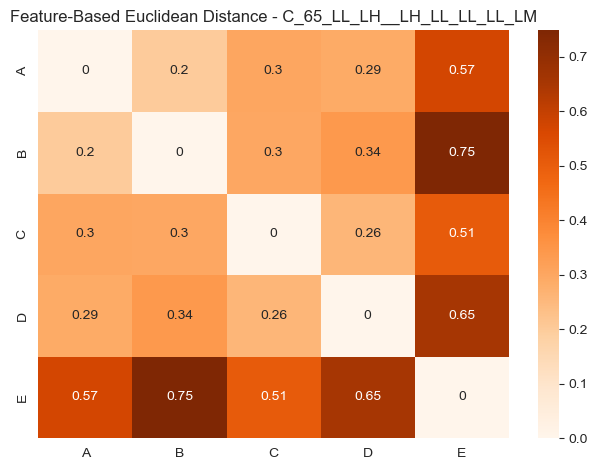

In [11]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt

for feat in all_series['feat'].unique():
    # Step 1: Filter feature block
    client_feat_series = all_series[(all_series['feat'] == feat)].drop(columns='feat')

    # Step 2: Get raw feature matrix and min-max scale it
    feature_matrix = client_feat_series.drop(columns='client').values
    scaler = MinMaxScaler()
    scaled_features = scaler.fit_transform(feature_matrix)

    # Step 3: Map each scaled row back to its client
    client_feat_series_scaled = pd.DataFrame(
        scaled_features,
        columns=client_feat_series.columns.drop('client'),
        index=client_feat_series.index
    )
    client_feat_series_scaled['client'] = client_feat_series['client'].values

    # Step 4: Create dictionary of client vectors
    client_vectors = {
        client: client_feat_series_scaled[client_feat_series_scaled['client'] == client].drop(columns='client').values
        for client in clients
    }

    # Step 5: Compute pairwise Euclidean distances
    feature_distances = pd.DataFrame(index=clients, columns=clients, dtype=float)

    for c1, c2 in combinations(clients, 2):
        v1 = client_vectors[c1]
        v2 = client_vectors[c2]
        dist = cosine_distances(v1, v2)[0][0]  # Euclidean distance
        feature_distances.loc[c1, c2] = dist
        feature_distances.loc[c2, c1] = dist

    np.fill_diagonal(feature_distances.values, 0)

    # Step 6: Plot
    sns.heatmap(feature_distances.astype(float), annot=True, cmap="Oranges")
    plt.title(f"Feature-Based Euclidean Distance - {case}")
    plt.tight_layout()
    plt.show()


In [ ]:


# ========== STEP 4: RANKING SIMILARITY ==========

# Average similarity per client (lower = more similar to others)
dtw_similarity_score = dtw_distances.mean(axis=1).sort_values()
feature_similarity_score = feature_distances.mean(axis=1).sort_values()

print("Ranking by DTW similarity:")
print(dtw_similarity_score)

print("\nRanking by Feature-based similarity:")
print(feature_similarity_score)
